In [12]:
%load_ext autoreload

import sys
import os
import pandas as pd
import numpy as np
import torch
import copy
import pandas as pd
import torch
import yaml

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
# def set_seed(seed):
#     # random.seed(seed)
#     # np.random.seed(seed)
#     torch.manual_seed(seed)
#     # torch.cuda.manual_seed(seed)
#     # torch.cuda.manual_seed_all(seed)  # Multi-GPU 환경 고려
#     # torch.backends.cudnn.deterministic = True
#     # torch.backends.cudnn.benchmark = False
#     print(f"Random seed set to: {seed}")

# SEED = 50
# set_seed(SEED)

In [14]:
# cost 0
cost_0_df = pd.read_csv("0.003_total_del_avg.csv", index_col=0)

In [4]:
# cost_0_model.index = cost_0_model.index.strftime('%Y-%m-%d')
# cost_1_model.index = cost_1_model.index.strftime('%Y-%m-%d')
# cost_2_model.index = cost_2_model.index.strftime('%Y-%m-%d')
# cost_4_model.index = cost_4_model.index.strftime('%Y-%m-%d')
# cost_5_model.index = cost_5_model.index.strftime('%Y-%m-%d')


In [16]:
benchmark_0 = pd.read_csv("../benchmark_del/0.003_benchmark.csv", index_col=0)

In [17]:
cost_0_df = pd.concat([cost_0_model, benchmark_0], axis=1)

In [19]:
def convert_to_log_returns(returns):
    """
    단순 수익률 데이터를 로그 수익률로 변환합니다.
    log(1 + r_t)
    """
    returns = np.asarray(returns, dtype=np.float64)
    return np.log1p(returns)  # np.log1p(x) = log(1 + x), 정확도 ↑

def calculate_log_cumulative_returns(returns):
    """
    누적 로그 수익률 시계열을 반환합니다.
    """
    log_returns = convert_to_log_returns(returns)
    return np.cumsum(log_returns)  # 시계열 형태로 반환


def calculate_annual_return(returns, annual_factor=252):
    returns = np.array(returns, dtype=np.float64)
    cumulative = np.prod(1 + returns)
    n_periods = len(returns)
    return cumulative ** (annual_factor / n_periods) - 1


def calculate_max_drawdown(returns):
    returns = np.array(returns, dtype=np.float64)
    cumulative_returns = np.cumprod(1 + returns)
    running_max = np.maximum.accumulate(cumulative_returns)
    drawdowns = (cumulative_returns - running_max) / running_max
    return abs(np.min(drawdowns))

def calculate_volatility(returns, annual_factor=252):
    returns = np.asarray(returns)
    return np.std(returns, ddof=1) * np.sqrt(annual_factor)


def calculate_downside_deviation(returns, threshold=0.0, annual_factor=252, annualize=True):
    downside = np.minimum(returns - threshold, 0)
    dd = np.sqrt(np.mean(downside ** 2))
    return dd * np.sqrt(annual_factor) if annualize else dd


def calculate_annualized_sortino_ratio(returns, risk_free_rate=0.02, annual_factor=252):
    annual_return = calculate_annual_return(returns, annual_factor)
    excess_return = annual_return - risk_free_rate
    downside_dev = calculate_downside_deviation(returns, threshold=0.0, annual_factor=annual_factor)
    return excess_return / downside_dev if downside_dev != 0 else 0.0


def calculate_calmar_ratio(returns, annual_factor=252):
    """
    Calmar Ratio = Annualized Return / Maximum Drawdown
    """
    returns = np.array(returns, dtype=np.float64)
    annual_return = calculate_annual_return(returns, annual_factor)
    max_drawdown = calculate_max_drawdown(returns)
    
    return  (annual_return) / max_drawdown if max_drawdown != 0 else 0.0  # MDD가 0이면 0 반환


# def calculate_sharpe_ratio(returns, risk_free_rate=0.02, annual_factor=12):
#     returns = np.array(returns, dtype=np.float64)
#     geo_return = np.prod(1 + returns) ** (1 / len(returns)) - 1
#     risk_free_rate /= annual_factor
#     excess_geo_return = geo_return - risk_free_rate
#     std_dev = np.std(returns, ddof=1)
#     return (excess_geo_return * annual_factor) / (std_dev * np.sqrt(annual_factor)) if std_dev != 0 else 0.0

def calculate_sharpe_ratio(returns, risk_free_rate=0.02, annual_factor=252):
    returns = np.array(returns, dtype=np.float64)
    annual_return = calculate_annual_return(returns, annual_factor)
    excess_return =  (annual_return - risk_free_rate) 
    if excess_return == 0:
        sign = 1
    else:
        sign = excess_return / abs(excess_return)
    annual_std_dev = calculate_volatility(returns, annual_factor)
    # 연환산 수익률과 표준편차
    modified_sharpe =  excess_return / (annual_std_dev ** sign)  if annual_std_dev != 0 else 0.0
    return modified_sharpe



def calculate_cumulative_return(returns):
    returns = np.array(returns, dtype=np.float64)
    return np.prod(1 + returns) - 1

def calculate_volatility(returns, annual_factor=252):
    returns = np.asarray(returns)
    return np.std(returns, ddof=1) * np.sqrt(annual_factor)


# 성과 지표 계산 함수 (파라미터화)
def calculate_performance_metrics(returns, annual_factor=252, risk_free_rate=0.0):
    cumulative_returns = (1 + returns).cumprod()
    # cagr = calculate_cagr(returns, annual_factor)
    annual_return = calculate_annual_return(returns, annual_factor)
    sharpe_ratio = calculate_sharpe_ratio(returns, risk_free_rate, annual_factor)
    mdd = calculate_max_drawdown(returns)
    volatility = calculate_volatility(returns, annual_factor)
    sortino_ratio = calculate_annualized_sortino_ratio(returns, risk_free_rate, annual_factor)
    downside_deviation = calculate_downside_deviation(returns, threshold=0.0, annual_factor=annual_factor)
    # Calmar Ratio 계산
    calmar_ratio = calculate_calmar_ratio(returns, annual_factor)
    log_cumulative_return = np.sum(np.log1p(returns))

    return {
        # 'Cumulative Return': cumulative_returns.iloc[-1] - 1,
        'Log Cumulative Return': log_cumulative_return,

        'Annual Return': annual_return,
        # 'CAGR': cagr,
        # 'Volatility': volatility,
        'Sharpe Ratio': sharpe_ratio,
        'MDD': mdd,
        # 'Downside Deviation': downside_deviation,
        'Sortino Ratio': sortino_ratio,
        'Calmar Ratio': calmar_ratio
    }


# 성과 지표 요약 생성 함수 (파라미터 전달)
def get_performance_summary(returns_dict, annual_factor=252, risk_free_rate=0.0):
    metrics_df = pd.DataFrame()
    for name, returns in returns_dict.items():
        metrics_df[name] = calculate_performance_metrics(returns, annual_factor, risk_free_rate)
    return metrics_df.T


# 성과 지표 요약 생성 함수 (파라미터 전달)
def get_performance_summary(returns_dict, annual_factor=252, risk_free_rate=0.0):
    metrics_df = pd.DataFrame()
    for name, returns in returns_dict.items():
        metrics_df[name] = calculate_performance_metrics(returns, annual_factor, risk_free_rate)
    return metrics_df.T


import matplotlib.pyplot as plt
import numpy as np




In [20]:
# total_return.to_csv("subperiod_total_average.csv")

In [21]:
cost_0_df.columns

Index(['GRPO', 'PPO', 'SAC', 'risk_parity', 'min_var', 'max_sharpe', 'paa',
       'equal_strategy', 'equal_asset_weight'],
      dtype='object')

In [22]:
def make_factor(df):
    imp = pd.DataFrame()
    for col in df.columns:
        model = df[col]
        gross_profit = model[model >= 0].sum()
        gross_loss = model[model < 0].sum()
        profit_factor = gross_profit / abs(gross_loss) if gross_loss != 0 else np.nan
        imp[col] = pd.Series({
            # 'gross_profit': gross_profit,
            # 'gross_loss': gross_loss,
            'profit_factor': profit_factor})
    return imp

In [23]:
metrics_summary = get_performance_summary(
    cost_0_df,
    annual_factor=12,
    risk_free_rate=0.0
)
metrics_summary = pd.concat([metrics_summary.T, make_factor(cost_0_df)], axis=0)


# metrics_summary = get_performance_summary(
#     cost_1_df,
#     annual_factor=12,
#     risk_free_rate=0.0
# )

# metrics_summary = pd.concat([metrics_summary.T, make_factor(cost_1_df)], axis=0)


# metrics_summary = get_performance_summary(
#     cost_2_df,
#     annual_factor=12,
#     risk_free_rate=0.0
# )
# metrics_summary = pd.concat([metrics_summary.T, make_factor(cost_2_df)], axis=0)



# metrics_summary = get_performance_summary(
#     cost_3_df,
#     annual_factor=12,
#     risk_free_rate=0.0
# )
# metrics_summary = pd.concat([metrics_summary.T, make_factor(cost_3_df)], axis=0)


# metrics_summary = get_performance_summary(
#     cost_4_df,
#     annual_factor=12,
#     risk_free_rate=0.0
# )
# metrics_summary = pd.concat([metrics_summary.T, make_factor(cost_4_df)], axis=0)


# metrics_summary = get_performance_summary(
#     cost_5_df,
#     annual_factor=12,
#     risk_free_rate=0.0
# )
# metrics_summary = pd.concat([metrics_summary.T, make_factor(cost_5_df)], axis=0)

# display(metrics_summary)

In [24]:
metrics_summary.T

,Log Cumulative Return,Annual Return,Sharpe Ratio,MDD,Sortino Ratio,Calmar Ratio,profit_factor
GRPO,1.100760,0.189823,1.180306,0.194461,2.422629,0.976146,2.659392
PPO,0.898088,0.152350,1.009921,0.205702,1.551502,0.740635,2.219874
SAC,0.563630,0.093074,0.621111,0.285355,0.923535,0.326170,1.706053
risk_parity,0.409444,0.066785,0.453082,0.254201,0.647539,0.262724,1.504703
min_var,0.736925,0.123396,1.081589,0.193105,1.853058,0.639013,2.246899
max_sharpe,0.406886,0.066354,0.315025,0.496835,0.472792,0.133553,1.395802
paa,0.592332,0.098039,0.566957,0.304134,0.848564,0.322355,1.640541
equal_strategy,0.563876,0.093117,0.685985,0.228384,1.011469,0.407721,1.774104
equal_asset_weight,0.400542,0.065286,0.415198,0.313931,0.590577,0.207963,1.474700


In [18]:
total_df = pd.DataFrame(grpo_best_strategy_returns)

In [20]:
zero_row = pd.DataFrame([[0]*total_return.shape[1]], columns=total_return.columns)


In [21]:
zero_row.index = ["2019-01-01"]

In [22]:
total_return = pd.concat([zero_row, total_return])


In [23]:
total_return.columns

Index(['GRPO', 'PPO', 'SAC', 'equal_strategy', 'equal_asset_weight',
       'risk_parity', 'min_var', 'max_sharpe', 'paa'],
      dtype='object')

In [24]:
rename_dict = {
    'risk_parity': 'Risk Parity',
    'min_var': 'Min Var',
    'max_sharpe': 'Max Sharpe',
    'paa': 'PAA',
    'equal_strategy': 'Equal Strategy',
    'equal_asset_weight' : 'Equal Asset Weight'
}

In [25]:
total_return.rename(columns=rename_dict, inplace=True)

In [26]:
total_return.columns

Index(['GRPO', 'PPO', 'SAC', 'Equal Strategy', 'Equal Asset Weight',
       'Risk Parity', 'Min Var', 'Max Sharpe', 'PAA'],
      dtype='object')

In [32]:
def plot_cumulative_returns_from_df(returns_df: pd.DataFrame,
                                     title='Cumulative Returns',
                                     y_range=(0.0, 5),
                                     test_start_date=None):

    plt.figure(figsize=(7, 4.5))  # A4 반절

    # datetime index 보장
    returns_df.index = pd.to_datetime(returns_df.index)

    cum_returns = np.log1p(returns_df).cumsum()

    bold_strategies = ['GRPO', 'PPO', 'SAC']
    color_map = {
        'SAC': '#1f77b4',
        'Min Var': '#ff7f0e',
        'Max Sharpe': '#2ca02c',
        'PAA': '#e377c2',
        'Equal Strategy': '#8c564b',
        'Risk Parity': '#bcbd22',
        'Equal Asset Weight': '#7f7f7f',
        'GRPO': '#000000',
        'PPO': '#ff0000',
    }

    for col in cum_returns.columns:
        linewidth = 3.5 if col in bold_strategies else 2.0
        color = color_map.get(col, None)
        plt.plot(cum_returns.index, cum_returns[col], label=col,
                 linewidth=linewidth, color=color)

    # x축 날짜 포맷 간격 조정
    ax = plt.gca()

    tick_idx = returns_df.index[::3]
    ax.set_xticks(tick_idx)
    ax.set_xticklabels(tick_idx.strftime('%Y-%m'), rotation=45, fontsize=9)
    # ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    # ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45, fontsize=10)

    if test_start_date:
        plt.axvline(x=test_start_date, color='red', linestyle='--', linewidth=2, label='Test Start')

    plt.ylim(y_range)
    plt.yticks(fontsize=12)
    plt.ylabel('Log Cumulative Returns', fontsize=13)
    plt.xlabel('Date', fontsize=13)
    plt.title(title, fontsize=15)

    # ✅ 범례를 바깥 오른쪽에 배치
    plt.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, -0.42),  # ↘ 더 아래
        ncol=3,
        fontsize=10,
        frameon=False
    )
    plt.grid(True)
    plt.subplots_adjust(bottom=0.35)  # 하단 여백 확보
    plt.savefig("figure/log_cum_return.png", dpi=600, bbox_inches='tight')

    plt.show()


In [33]:
total_return

,GRPO,PPO,SAC,Equal Strategy,Equal Asset Weight,Risk Parity,Min Var,Max Sharpe,PAA
2019-01-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2019-01-30,-0.023335,0.019726,0.030210,0.004488,0.054332,0.055960,0.031233,-0.045906,-0.023335
2019-02-28,0.015721,0.009734,0.006705,-0.003551,0.016301,0.017790,0.007447,-0.022495,-0.016946
2019-03-28,-0.008980,-0.008134,-0.010164,-0.011249,-0.004392,-0.006875,-0.012137,-0.013190,-0.012795
2019-04-26,0.002209,0.021928,0.012148,0.015008,0.024158,0.022650,-0.002901,0.019038,0.021245
...,...,...,...,...,...,...,...,...,...
2024-09-20,0.011247,0.001493,0.032385,0.028014,0.034407,0.034817,0.049867,0.025878,0.001493
2024-10-18,0.010479,0.016962,0.004471,0.005103,0.002778,0.003926,-0.001231,0.000756,0.016962
2024-11-15,-0.022477,-0.020190,-0.031152,-0.030522,-0.020486,-0.044229,-0.033668,-0.023999,-0.020194
2024-12-16,0.065416,0.078830,0.036831,0.048389,0.036143,0.020330,0.032332,0.062063,0.078830


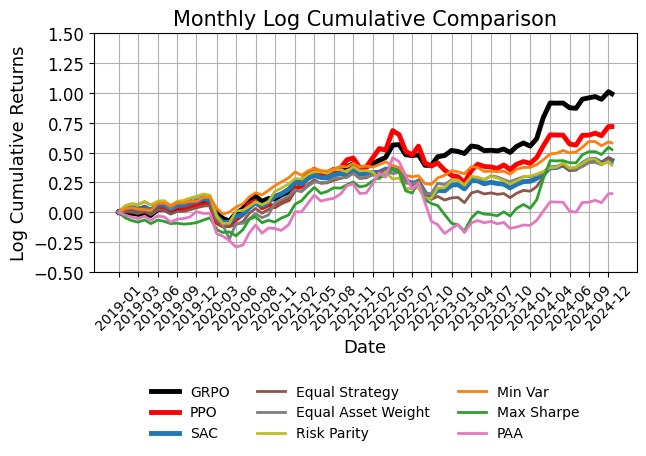

In [34]:
plot_cumulative_returns_from_df(total_return, title="Monthly Log Cumulative Comparison", y_range=(-0.5, 1.5))


In [38]:
def plot_cumulative_returns_from_df(returns_df: pd.DataFrame,
                                     title='Cumulative Returns',
                                     y_range=(0.0, 5),
                                     test_start_date=None):
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    import numpy as np

    # 적절한 사이즈 (A4 절반 수준)
    plt.figure(figsize=(6, 4))

    # 누적 로그 수익률 계산
    cum_returns = np.log1p(returns_df).cumsum()

    bold_strategies = ['GRPO', 'PPO']  # 대소문자 확인
    color_map = {
        'GRPO': 'black',
        'PPO': 'red',
        'SAC': 'skyblue',
        'Equal Strategy': 'brown',
        'Equal Asset Weight': 'gray',
        'Risk Parity': 'yellowgreen',
        'Min Var': 'orange',
        'Max Sharpe': 'green',
        'PAA': 'violet',
    }

    for col in cum_returns.columns:
        linewidth = 2.5 if col in bold_strategies else 1.5
        plt.plot(
            cum_returns.index,
            cum_returns[col],
            label=col,
            linewidth=linewidth,
            color=color_map.get(col, None)
        )

    # x축 날짜 간격과 포맷 정리
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # 3개월 간격
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45, fontsize=10)

    # 범례 위치 조정
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=9)

    plt.ylim(y_range)
    plt.yticks(fontsize=10)
    plt.ylabel('Log Cumulative Returns', fontsize=12)
    plt.xlabel('Date', fontsize=11)
    plt.title(title, fontsize=14)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


,GRPO,PPO,SAC,Equal Strategy,Equal Asset Weight,Risk Parity,Min Var,Max Sharpe,PAA
2019-01-30,-0.023335,0.019726,0.030210,0.004488,0.054332,0.055960,0.031233,-0.045906,-0.023335
2019-02-28,0.015721,0.009734,0.006705,-0.003551,0.016301,0.017790,0.007447,-0.022495,-0.016946
2019-03-28,-0.008980,-0.008134,-0.010164,-0.011249,-0.004392,-0.006875,-0.012137,-0.013190,-0.012795
2019-04-26,0.002209,0.021928,0.012148,0.015008,0.024158,0.022650,-0.002901,0.019038,0.021245
2019-05-24,-0.011915,-0.027820,-0.020592,-0.024924,-0.027220,-0.025741,-0.008459,-0.030936,-0.034561
...,...,...,...,...,...,...,...,...,...
2024-09-20,0.011247,0.001493,0.032385,0.028014,0.034407,0.034817,0.049867,0.025878,0.001493
2024-10-18,0.010479,0.016962,0.004471,0.005103,0.002778,0.003926,-0.001231,0.000756,0.016962
2024-11-15,-0.022477,-0.020190,-0.031152,-0.030522,-0.020486,-0.044229,-0.033668,-0.023999,-0.020194
2024-12-16,0.065416,0.078830,0.036831,0.048389,0.036143,0.020330,0.032332,0.062063,0.078830


In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
df = total_return.iloc[1:]
# long-form으로 변환

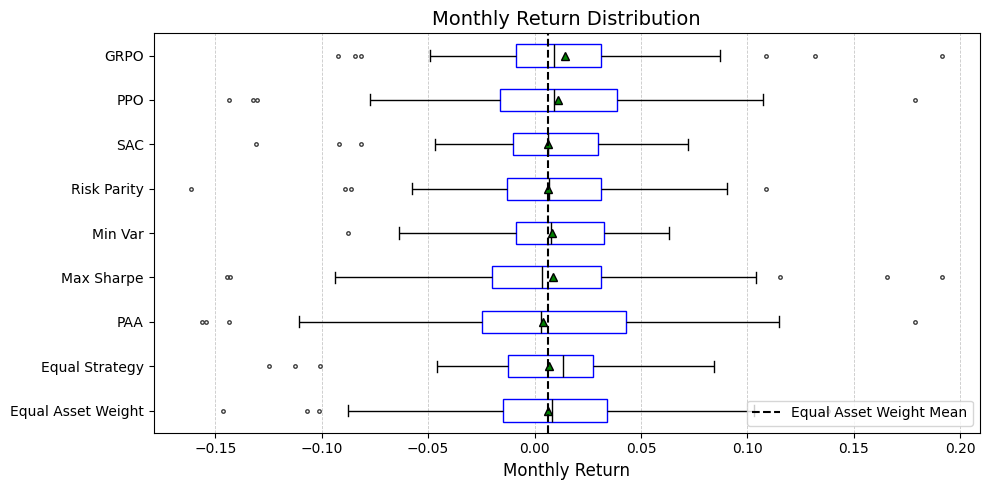

In [54]:
# 예시용 DataFrame (실제 df로 대체)
# df = pd.DataFrame({...})

# 컬럼 순서 (원하는 순서로)
strategy_order = ['GRPO', 'PPO', 'SAC',
         'Risk Parity', 'Min Var', 'Max Sharpe',
         'PAA', 'Equal Strategy', 'Equal Asset Weight']
# 박스플롯 스타일 설정
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df[strategy_order],
    orient='h',
    width=0.5,
    fliersize=2.5,
    linewidth=1,
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "green",
        "markeredgecolor": "black",
        "markersize": 6
    },
    boxprops=dict(facecolor='white', edgecolor='blue'),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    medianprops=dict(color='black'),
)

plt.title('Monthly Return Distribution', fontsize=14)
plt.xlabel('Monthly Return', fontsize=12)
plt.ylabel('')
plt.grid(axis='x', linestyle='--', linewidth=0.6, alpha=0.7)

# 수평 벤치마크 라인 추가 (예: SP500 평균 기준)
benchmark_value = df['Equal Asset Weight'].mean()
plt.axvline(
    x=benchmark_value,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label='Equal Asset Weight Mean',
    zorder=5
)

plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig("figure/Monthly_return_distribution.png", dpi=600, bbox_inches='tight')

plt.show()


In [56]:
imp = total_df[["equal_strategy", "equal_asset_weight"]]

In [61]:
imp.to_csv("./portfolio_price_discrete_rebal_step_1m_concat_asset/result/equal_strategy.csv")